In [36]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage

from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [37]:
llm = ChatGoogleGenerativeAI(model='gemini-flash-latest')

In [38]:
search_tool = DuckDuckGoSearchRun(region='us-en')

@tool
def calculator(first_num:float,second_num:float,operation:str)->dict:
    """Perform a basic arithmetic operation on two numbers.
    Supported operations: add,sub,mul,div
    """
    try:
        if operation == "add":
            result = first_num+second_num
        elif operation == 'sub':
            result = first_num-second_num
        elif operation == 'mul':
            result = first_num*second_num
        elif operation == 'div':
            if second_num == 0:
                return {'error':'Division by zero is not allowed'}
            result = first_num/second_num
        else:
            return {"error":f"Unsupported operation '{operation}"}
        return {'first_num':first_num,'second_num':second_num,'operation':operation,'result':result}
    except Exception as e:
        return {'error':str(e)}


@tool 
def get_stock_price(symbol:str)->dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL','TSLA')
    using Alpha Vantage with AOI key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTES&symbol={symbol}&apikey=F4GSQNRHMGGJIDYQ"
    r = requests.get(url)
    return r.json()

In [39]:
tools = [get_stock_price,search_tool,calculator]

llm_with_tools = llm.bind_tools(tools)

In [40]:
class chatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [47]:
def chat_node(state:chatState):
    """LLM node that may appear or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages':[response]}

tool_node = ToolNode(tools) # Execute tool nodes

In [48]:
graph = StateGraph(chatState)

graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)


In [49]:
graph.add_edge(START,"chat_node")

# if llm asks for a tool, go to ToolNode else finish
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

In [50]:
workflow = graph.compile()

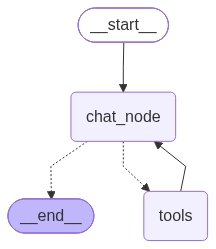

In [51]:
workflow

In [ ]:
out = workflow.invoke({'messages':[HumanMessage(content='What is the stock price of Apple. How much is the cost for 50 shares')]})
print(out['messages'][-1].content)

DDGSException: module 'httpcore._sync' has no attribute 'http2'